# Lesson 2. The PID and a failing controller

Work from top to bottom. This lesson stays in graphs. It does not open a 3D
window.

## Learning objectives

By the end of this lesson you will be able to:

1. Define proportional, integral, and derivative action for bicycle roll.
2. Trace one step of the outer PID from sensor values to a steer-rate command.
3. Distinguish the outer balance loop from the inner motor loop.
4. Read a roll graph of a controller that reacts and then fails.

## Glossary

| Term | Meaning |
| --- | --- |
| Roll | Lean from upright, in degrees. 0° is upright. |
| Error | Desired value minus measured value. Desired roll is 0, so a lean of +3° is an error of −3°. |
| Gain | A multiplier on an error. A larger gain produces a stronger command for the same error. |
| Torque | A twisting effort from a motor. Steering torque turns the handlebars. |
| Steer rate | How fast the handlebars are turning, in radians per second. About 1 rad/s is 57°/s. |
| PID | Proportional + integral + derivative. Three terms added into one command. |
| Outer loop | The PID that converts lean into a desired handlebar speed. |
| Inner loop | A smaller PI that converts that desired speed into motor torque. |
| YAML | A text file of named numbers. `configs/tutorial.yaml` is the control panel for this lesson. |
| Saturation | The command has hit its allowed maximum and cannot grow further. |


## Step 1. Start the lesson

Run the next cell. It locates the project and prepares graphs. Continue when
you see `project_root:`.


In [1]:
import os
import sys

def choose_mujoco_gl(platform, display, existing):
    if existing:
        return existing
    if str(platform).startswith("linux") and not display:
        return "egl"
    return None

chosen = choose_mujoco_gl(sys.platform, os.environ.get("DISPLAY"), os.environ.get("MUJOCO_GL"))
if chosen and "MUJOCO_GL" not in os.environ:
    os.environ["MUJOCO_GL"] = chosen

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace

from sim.config import load_config
from sim.loop import make_sim, run_headless, summarize
from sim.pid_controller import RollSteerPID, apply_speed_refs

np.set_printoptions(precision=4, suppress=True)
print("project_root:", project_root)
print("platform:", sys.platform, "MUJOCO_GL:", os.environ.get("MUJOCO_GL", "(unset)"))


from sim.sensors import wrap_angle


project_root: /home/lmbike2/bike-workshop/bike_mujoco_sim
platform: linux MUJOCO_GL: egl


## Step 2. Compute one PID step by hand

The outer controller is the class `RollSteerPID` in `sim/pid_controller.py`.
Every 0.02 s (50 times per second) it does the following:

1. Roll error = desired roll − measured roll. Desired roll is 0.
2. Steer error = desired bar angle − measured bar angle. The angle is wrapped
   so a full rotation still appears as a small number.
3. Add `error × time step` to the integral, then clip the integral.
4. Add four terms:
   - **P** reacts to the lean itself. A larger lean produces a larger command.
   - **D** reacts to roll rate, how fast the lean is changing. This is the
     term that catches a fall.
   - **I** reacts to a lean that persists. It is small on the first step.
   - **Steer term** pulls the handlebars back toward straight.
5. Limit the sum so the requested bar speed cannot exceed `max_steer_velocity`.

The next cell uses a sample lean of +3° and a sample fall rate of +20°/s.
The printed units are radians per second of desired bar speed, not motor
torque. Expect the D term to dominate, because the lean is changing quickly,
and the I term to be near zero on this first step.


In [2]:
tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
cfg = load_config(tutorial_yaml)
pid = RollSteerPID(
    kp_roll=cfg.pid_kp_roll,
    ki_roll=cfg.pid_ki_roll,
    kd_roll=cfg.pid_kd_roll,
    kp_steer=cfg.pid_kp_steer,
    max_steer_velocity=cfg.max_steer_velocity,
    integral_limit=cfg.pid_integral_limit,
)

roll = float(np.deg2rad(3.0))
roll_rate = float(np.deg2rad(20.0))
steer = 0.0
dt = cfg.control_dt
e_roll = 0.0 - roll
e_steer = 0.0 - wrap_angle(steer)
pid.integral = 0.0
pid.integral = max(-pid.integral_limit, min(pid.integral_limit, pid.integral + e_roll * dt))
p_term = pid.kp_roll * e_roll
i_term = pid.ki_roll * pid.integral
d_term = pid.kd_roll * (-roll_rate)
s_term = pid.kp_steer * e_steer
raw = p_term + i_term + d_term + s_term
cmd = float(max(-pid.max_steer_velocity, min(pid.max_steer_velocity, raw)))
print("roll = +3 deg, roll_rate = +20 deg/s")
print(f"  P term {p_term:+.3f} rad/s")
print(f"  I term {i_term:+.3f} rad/s")
print(f"  D term {d_term:+.3f} rad/s")
print(f"  steer term {s_term:+.3f} rad/s")
print(f"  clipped command {cmd:+.3f} rad/s")
print("library step()", pid.step(steer=steer, roll=roll, roll_rate=roll_rate, dt=dt))


roll = +3 deg, roll_rate = +20 deg/s
  P term -0.262 rad/s
  I term -0.000 rad/s
  D term -2.094 rad/s
  steer term +0.000 rad/s
  clipped command -2.356 rad/s
library step() -2.356194490192345


## Step 3. Identify the inner motor loop

The outer PID requests a bar speed. The motor still needs a torque. In
`sim/loop.py` the inner loop is:

1. Compare the desired bar speed with the measured bar speed.
2. Integrate that speed error.
3. Torque = `steer_kp × error + steer_ki × integral`.

`steer_kp` and `steer_ki` belong to the motor. Leave them unchanged. The
balance knobs are the outer `pid_*` names.


## Step 4. Open the control panel

`configs/tutorial.yaml` stores the gains as named numbers. Open that file in
the editor.

| Name | Role |
| --- | --- |
| `pid_kp_roll` | Proportional gain on roll |
| `pid_ki_roll` | Integral gain on roll |
| `pid_kd_roll` | Derivative gain on roll rate |
| `pid_kp_steer` | Gain that straightens the handlebars |

The file starts with a weak set on purpose. The controller will move the
bars and the bicycle will still fall. Do not change `steer_kp` or
`steer_ki`.

Run the next cell and confirm the printed outer gains are near 5, 0, 6, and
1.12.


In [3]:
tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
cfg = load_config(tutorial_yaml)
print("loaded", os.path.relpath(tutorial_yaml, project_root))
print(
    "outer gains: kp_roll={:.3f} ki_roll={:.3f} kd_roll={:.3f} kp_steer={:.3f}".format(
        cfg.pid_kp_roll, cfg.pid_ki_roll, cfg.pid_kd_roll, cfg.pid_kp_steer
    )
)
print("inner motor: steer_kp={:.4f} steer_ki={:.4f}".format(cfg.steer_kp, cfg.steer_ki))


loaded configs/tutorial.yaml
outer gains: kp_roll=5.000 ki_roll=0.000 kd_roll=6.000 kp_steer=1.116
inner motor: steer_kp=0.0344 steer_ki=0.0213


## Step 5. Run the controller from the settings file

The first cell opens the 3D window with the gains in `configs/tutorial.yaml`.
Close that window, then run the graph cell. The graph cell uses the same
gains for 6 seconds and draws:

1. Roll versus time. The dashed lines are ±45°. A dotted line marks the first crossing, if there is one.
2. Steer-rate command versus time. A flat ceiling means the command is saturated.

Decide from the first second whether the command stays at 0, and whether roll crosses 45°.

If the window cell reports that MuJoCo was already imported, choose
**Kernel → Restart Kernel**, then run the window cell again.


In [ ]:
import os
import sys

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

if "mujoco" in sys.modules and os.environ.get("MUJOCO_GL") not in (None, "", "glfw"):
    raise RuntimeError(
        "MuJoCo was already imported with MUJOCO_GL=%r. Restart the kernel, "
        "then run this cell again." % os.environ.get("MUJOCO_GL")
    )
os.environ["MUJOCO_GL"] = "glfw"

from dataclasses import replace
from sim.config import load_config
from sim.loop import make_sim
from sim.viewer import run_viewer

print("project_root:", project_root)
print("MUJOCO_GL:", os.environ.get("MUJOCO_GL"))


tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
cfg = load_config(tutorial_yaml)
cfg = replace(cfg, duration=6.0)
sim = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=cfg)
print("gains from", os.path.relpath(tutorial_yaml, project_root))
print("pid_kd_roll", cfg.pid_kd_roll, "pid_kp_roll", cfg.pid_kp_roll)
print("Close the MuJoCo window to finish this cell.")
run_viewer(sim)
print("Window closed.")


model:      /home/lmbike2/bike-workshop/bike_mujoco_sim/models/new_bike/new_bike.xml
mode:       struggle
simulated:  6.00s
max |roll|: 97.85 deg
final speed:-6.466 m/s
mean |roll|: 78.83 deg
WARN: large lean — likely tipped. Retune PID / inner gains (new_bike is harder than orange_bike).


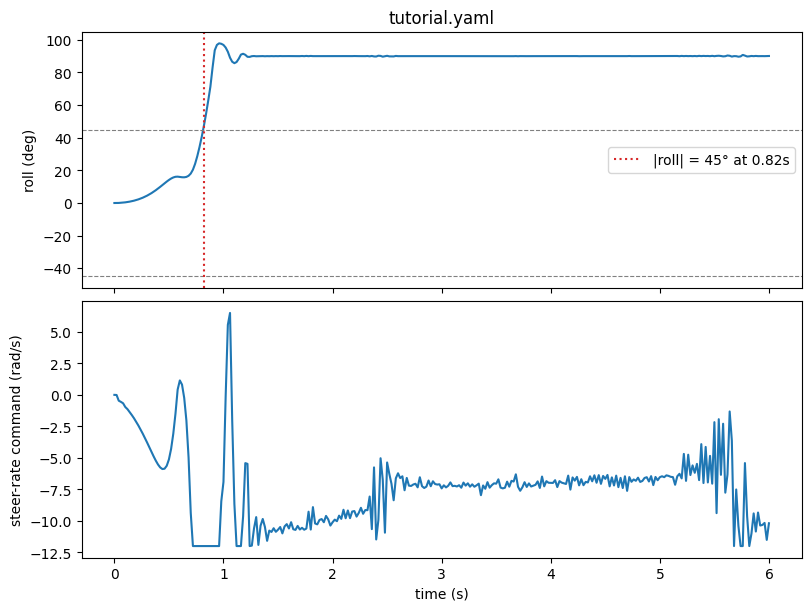

max |roll| = 97.8 deg
t=0.20s  roll=  +1.8 deg  rate_cmd=-2.14 rad/s
t=0.40s  roll=  +8.9 deg  rate_cmd=-5.53 rad/s
t=0.60s  roll= +16.0 deg  rate_cmd=+1.15 rad/s
t=0.80s  roll= +40.3 deg  rate_cmd=-12.00 rad/s


In [5]:
tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
cfg = load_config(tutorial_yaml)
cfg = replace(cfg, duration=6.0)
sim = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=cfg)
history = run_headless(sim, duration=6.0)
summarize(history, model_path=sim.model_path, mode="struggle")

time_s = np.asarray(history["time"], dtype=float)
roll_deg = np.degrees(np.asarray(history["roll"], dtype=float))
rate_cmd = np.asarray(history["steer_rate_ref"], dtype=float)
tip = np.where(np.abs(roll_deg) > 45.0)[0]
tip_t = float(time_s[tip[0]]) if len(tip) else None

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True, constrained_layout=True)
axes[0].plot(time_s, roll_deg)
axes[0].axhline(45, color="0.5", linestyle="--", linewidth=0.8)
axes[0].axhline(-45, color="0.5", linestyle="--", linewidth=0.8)
if tip_t is not None:
    axes[0].axvline(tip_t, color="C3", linestyle=":", label=f"|roll| = 45° at {tip_t:.2f}s")
    axes[0].legend()
axes[0].set_ylabel("roll (deg)")
axes[0].set_title("tutorial.yaml")
axes[1].plot(time_s, rate_cmd)
axes[1].set_ylabel("steer-rate command (rad/s)")
axes[1].set_xlabel("time (s)")
plt.show()

print(f"max |roll| = {float(np.max(np.abs(roll_deg))):.1f} deg")
if tip_t is None:
    raise RuntimeError("expected this weak gain set to tip")
# Show a few samples before the tip for the write-up.
for ti in (0.2, 0.4, 0.6, 0.8):
    i = int(np.argmin(np.abs(time_s - ti)))
    if time_s[i] <= tip_t + 0.05:
        print(f"t={time_s[i]:.2f}s  roll={roll_deg[i]:+6.1f} deg  rate_cmd={rate_cmd[i]:+.2f} rad/s")


## Discussion

### Why did the steer command move if the bicycle still fell?

The PID was active. The command left zero and often hit its speed limit. In the starting file `pid_kd_roll` is about 6, which is too small to stop the fall rate, so roll passed 45° near 0.8 s.

### Is this the wobble from a proportional gain that is too high?

This trace is a short fight and then a one-way fall. A proportional gain that is much too large, without enough derivative gain, can grow into a left-right oscillation. That is a different failure from the one in this file.

### Which term was doing the work in the sample step?

For a lean of +3° and a fall rate of +20°/s, the D term is the large one, because it reacts to how fast the lean is changing. The I term has barely started on the first step.

### Which numbers am I allowed to change?

The four outer gains in `configs/tutorial.yaml`. The inner motor gains, `steer_kp` and `steer_ki`, stay fixed.


## Questions

Answer these before you run the next cell.

1. For the sample lean of +3° and the sample fall rate of +20°/s, which term had the largest magnitude: P, I, D, or the steer term?
2. Predict `pid_kd_roll = 11`, with the other gains left as they are in `configs/tutorial.yaml`: fall, or hold under 45°?

The cell first names the largest term from the file's gains, using the same sample as Step 2. Compare that name with your answer to question 1.

Then it rides with `kd_try`. Start at `6.0`. Run the cell again with `11.0`. Compare the result line with your prediction.


In [6]:
tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
cfg = load_config(tutorial_yaml)
roll = float(np.deg2rad(3.0))
roll_rate = float(np.deg2rad(20.0))
terms = {
    "P": abs(cfg.pid_kp_roll * (0.0 - roll)),
    "I": abs(cfg.pid_ki_roll * (0.0 - roll) * cfg.control_dt),
    "D": abs(cfg.pid_kd_roll * roll_rate),
    "steer": 0.0,
}
print("largest term on the +3 deg, +20 deg/s sample:", max(terms, key=terms.get))

# Edit kd_try and run again. Trials: 6.0, then 11.0
kd_try = 6.0
cfg = replace(cfg, pid_kd_roll=float(kd_try), duration=4.0)
sim = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=cfg)
history = run_headless(sim, duration=4.0)
time_s = np.asarray(history["time"], dtype=float)
roll_deg = np.degrees(np.asarray(history["roll"], dtype=float))
tip = np.where(np.abs(roll_deg) > 45.0)[0]
tip_t = float(time_s[tip[0]]) if len(tip) else None
print(f"pid_kd_roll = {cfg.pid_kd_roll}")
print(f"max |roll| = {float(np.max(np.abs(roll_deg))):.1f} deg")
if tip_t is None:
    print("Result: held. Roll stayed under 45 deg.")
else:
    print(f"Result: fell at {tip_t:.2f} s.")


largest term on the +3 deg, +20 deg/s sample: D


pid_kd_roll = 6.0
max |roll| = 97.8 deg
Result: fell at 0.82 s.
